In [60]:
IS_ONLINE_JUDGE = False
DEBUG = True
DEBUG_QUERY = 400
DEBUG_L = 100

if IS_ONLINE_JUDGE:
    DEBUG = False

# =================================
import time

GLOBAL_START_TIME = time.perf_counter()


def debug_print(*args, **kwargs):
    if IS_ONLINE_JUDGE:
        return
    print(*args, **kwargs)


def print_elapsed_time():
    debug_print(f"elapsed time: {(time.perf_counter() - GLOBAL_START_TIME) * 1000:.2f}msecs")


# =================================
import heapq
import math
import random
from collections import defaultdict

random.seed(0)

INF = 10**18
FILE_NUM = 100


# =================================
def calc_rectangle_area(rectangle):
    l, r, t, b = rectangle
    area = (r - l) * (b - t)
    return area


def get_four_points_from_rectangle(rectangle):
    l, r, t, b = rectangle
    points = [
        (l, t),  # top left
        (r, t),  # top right
        (r, b),  # bottom right
        (l, b),  # bottom left
    ]
    return points


def calc_rectangle_dist(rectangle1, rectangle2):
    ps1 = get_four_points_from_rectangle(rectangle1)
    ps2 = get_four_points_from_rectangle(rectangle2)

    dists = []
    for p1 in ps1:
        for p2 in ps2:
            dist = calc_dist(p1, p2)
            dists.append(dist)
    return max(dists)


def calc_dist(p1: tuple, p2: tuple) -> float:
    return math.dist(p1, p2)


def prim(
    graph: dict[int, list[tuple[int, int]]],
) -> tuple[list[tuple[int, int]], list[int]]:
    """
    G: 隣接グラフ
    G := [ [(v_0, cost_0), (v_1,cost_1),..], [(v_2, cost_2)],...]

    返り値 ans :最小全域木の重みの総和
    """
    v_list = list(graph.keys())
    used = {v: False for v in v_list}

    init_v = v_list[0]  # 適当な点を選ぶ
    used[init_v] = True
    que = [(cost, init_v, v) for v, cost in graph[init_v]]
    heapq.heapify(que)

    ans_v: list[int] = [init_v]
    ans_edges: list[tuple[int, int]] = []
    while que:
        cost_v, from_v, to_v = heapq.heappop(que)
        if used[to_v]:
            continue
        used[to_v] = True
        ans_edges.append((min(from_v, to_v), max(from_v, to_v)))
        ans_v.append(to_v)
        for nxt, cost_nxt in graph[to_v]:
            if used[nxt]:
                continue
            heapq.heappush(que, (cost_nxt, to_v, nxt))
    return ans_edges, ans_v


def prim_k(graph: list[list[float]], init_v: int, k: int, used_v: set[int], N):
    """
    init_vを含むk頂点の最小全域木を求める
    """
    used = used_v | {init_v}
    used.add(init_v)
    que = [(graph[init_v][v], init_v, v) for v in range(N)]
    heapq.heapify(que)

    ans_v = [init_v]
    ans_edges: list[tuple[int, int]] = []
    ans_cost = 0.0
    while que and len(ans_v) < k:
        cost_v, from_v, to_v = heapq.heappop(que)
        if to_v in used:
            continue
        used.add(to_v)
        ans_edges.append((min(from_v, to_v), max(from_v, to_v)))
        ans_v.append(to_v)
        ans_cost += cost_v
        for nxt in range(N):
            if nxt in used:
                continue
            heapq.heappush(que, (graph[to_v][nxt], to_v, nxt))
    return ans_edges, ans_v, ans_cost


# =================================


class EnvOffline:
    def __init__(self, input_file_path: str, output_file_path: str):
        with open(input_file_path) as f:
            lines = f.readlines()
            N, M, Q, L, W = map(int, lines[0].split())
            G = list(map(int, lines[1].split()))
            rectangles = []
            for l in range(2, 2 + N):
                rectangles.append(list(map(int, lines[l].split())))
            coordinates = []
            for l in range(2 + N, 2 + N + N):
                coordinates.append(tuple(map(int, lines[l].split())))

        self.N, self.M, self.Q, self.L, self.W = N, M, Q, L, W
        self.G = G
        self.rectangles = rectangles
        self.coordinates = coordinates
        self.cneter_points = [((l + r) / 2, (c + d) / 2) for l, r, c, d in rectangles]
        self._query_history: list[str] = []

        self.input_file_path = input_file_path
        self.output_file_path = output_file_path

        if DEBUG:
            self.L = DEBUG_L
            self.Q = DEBUG_QUERY

    def query(self, c_list: list[int]) -> list[tuple[int, int]]:
        query_str = " ".join(["?", str(len(c_list)), *map(str, c_list)])
        self._query_history.append(query_str)

        now_graph: dict[int, list] = {v: [] for v in c_list}
        for c1 in c_list:
            for c2 in c_list:
                if c1 == c2:
                    continue
                x1, y1 = self.coordinates[c1]
                x2, y2 = self.coordinates[c2]
                dist = calc_dist((x1, y1), (x2, y2))
                now_graph[c1].append((c2, dist))
                now_graph[c2].append((c1, dist))

        ans_edges, ans_v = prim(now_graph)
        return ans_edges

    def answer(
        self,
        groups: list[list[int]],
        edges: list[list[tuple[int, int]]],
    ):
        cost = 0.0
        ans_str = "!\n"
        for i in range(len(groups)):
            ans_str += " ".join(map(str, groups[i])) + "\n"
            for e in edges[i]:
                ans_str += " ".join(map(str, e)) + "\n"
                dist = calc_dist(self.coordinates[e[0]], self.coordinates[e[1]])
                cost += dist

        for query_str in self._query_history:
            ans_str += query_str + "\n"

        with open(self.output_file_path, "w") as f:
            f.write(ans_str)

        if len(self._query_history) > self.Q:
            debug_print(f"!!!query limit exceeded {len(self._query_history)}/{self.Q}")
        else:
            debug_print(f"query: {len(self._query_history)}")

        return cost


class EnvOnline:
    def __init__(self):
        N, M, Q, L, W = map(int, input().split())
        G = list(map(int, input().split()))
        rectangles = []
        for l in range(N):
            rectangles.append(list(map(int, input().split())))

        self.N, self.M, self.Q, self.L, self.W = N, M, Q, L, W
        self.G = G
        self.rectangles = rectangles
        self.cneter_points = [((l + r) / 2, (c + d) / 2) for l, r, c, d in rectangles]

    def query(self, c_list: list[int]) -> list[tuple[int, int]]:
        query_str = " ".join(["?", str(len(c_list)), *map(str, c_list)])
        print(query_str)
        return [tuple(map(int, input().split())) for _ in range(len(c_list) - 1)]

    def answer(
        self,
        groups: list[list[int]],
        edges: list[list[tuple[int, int]]],
    ):
        ans_str = "!\n"
        for i in range(len(groups)):
            ans_str += " ".join(map(str, groups[i])) + "\n"
            for e in edges[i]:
                ans_str += " ".join(map(str, e)) + "\n"
        print(ans_str)


def calc_greedy_answer(env: EnvOffline):
    graph: list[list[float]] = [[0 for _ in range(env.N)] for _ in range(env.N)]
    for i in range(env.N):
        for j in range(env.N):
            if i == j:
                continue
            dist = calc_dist(env.cneter_points[i], env.cneter_points[j])
            # dist = calc_rectangle_dist(env.rectangles[i], env.rectangles[j])
            graph[i][j] = dist
            graph[j][i] = dist

    groups = [(i, g) for i, g in enumerate(env.G)]
    groups = sorted(groups, key=lambda x: x[1], reverse=True)

    ans_edges = [None for _ in range(len(groups))]
    ans_v = [None for _ in range(len(groups))]

    now_used: set = set()
    not_used: set = set(range(env.N))
    for group_n, group_size in groups:
        v = not_used.pop()
        prim_edges, prim_v, _ = prim_k(graph, v, group_size, now_used, env.N)

        ans_edges[group_n] = prim_edges
        ans_v[group_n] = prim_v
        now_used.update(prim_v)
        not_used.difference_update(prim_v)

    return ans_v, ans_edges


class MyGraph:
    def __init__(self, vs, edges, group_ind):
        self.vs = vs
        self.edges = edges
        self.group_ind = group_ind

        self.visited_cnt = {v: 0 for v in vs}
        self._construct_graph()

    def _construct_graph(self):
        graph = defaultdict(list)
        for i, e in enumerate(self.edges):
            graph[e[0]].append(e[1])
            graph[e[1]].append(e[0])
        self.graph = graph

    def update_edges(self, remove_edge, add_edges):
        self.edges = list(set(self.edges) - set(remove_edge) | set(add_edges))
        self._construct_graph()

    def choice_min_visited(self):
        min_v = min(self.visited_cnt.values())
        min_vs = [v for v, cnt in self.visited_cnt.items() if cnt == min_v]
        return random.choice(min_vs)

    def walk_bfs(self, init_v, q_num):
        visited_v = set()
        visited_edge = set()
        q = [(None, init_v)]
        while q and len(visited_v) < q_num:
            random.shuffle(q)
            pv, v = q.pop()
            if v in visited_v:
                continue
            if pv is not None:
                visited_edge.add((min(pv, v), max(pv, v)))
            visited_v.add(v)
            for nv in self.graph[v]:
                if nv not in visited_v:
                    q.append((v, nv))

        for v in visited_v:
            self.visited_cnt[v] += 1

        return visited_v, visited_edge


def update_mst(env: EnvOffline, ans_v, ans_edges):
    group_query_cnt = [0 for _ in range(env.M)]
    group_query_v_cnt = [0 for _ in range(env.M)]

    largest_groups = []
    for g in range(env.M):
        if 3 <= len(ans_v[g]):
            group_query_cnt[g] += 1
            group_query_v_cnt[g] += env.L
            if env.L < len(ans_v[g]):
                largest_groups.append(g)

    for _ri in range(env.Q - sum(group_query_cnt)):
        min_cost = 10**9
        target_group = None
        for g in largest_groups:
            cost = group_query_v_cnt[g] / len(ans_v[g])
            if cost < min_cost:
                min_cost = cost
                target_group = g
        if target_group is not None:
            group_query_v_cnt[target_group] += env.L
            group_query_cnt[target_group] += 1

    for g in range(env.M):
        now_v = ans_v[g]
        now_edges = ans_edges[g]
        if len(now_v) < 3:
            if group_query_cnt[g] > 0:
                print(g, "ERROR")
            continue
        if 3 <= len(now_v) <= env.L:
            ans_edges[g] = env.query(now_v)
            continue

        my_graph = MyGraph(now_v, now_edges, g)
        for _ in range(group_query_cnt[g]):
            rand_v = my_graph.choice_min_visited()
            visited_v, visited_edge = my_graph.walk_bfs(rand_v, env.L)
            new_edges = env.query(visited_v)
            my_graph.update_edges(visited_edge, new_edges)
        ans_edges[g] = my_graph.edges

    return ans_v, ans_edges


def solve(env: EnvOffline):
    ans_v, ans_edges = calc_greedy_answer(env)
    ans_v, ans_edges = update_mst(env, ans_v, ans_edges)
    return ans_v, ans_edges


def main():
    if IS_ONLINE_JUDGE:
        env = EnvOnline()
        ans_v, ans_edges = solve(env)
        env.answer(ans_v, ans_edges)
    else:
        costs = []
        for file_num in range(FILE_NUM):
            debug_print("=====")
            start_time = time.perf_counter()
            input_file_path = f"../in/{file_num:04d}.txt"
            output_file_path = f"../out/{file_num:04d}.txt"
            #####
            env = EnvOffline(input_file_path, output_file_path)
            ans_v, ans_edges = solve(env)
            cost = env.answer(ans_v, ans_edges)
            #####
            debug_print(f"[{file_num}/{FILE_NUM}]: {cost} {time.perf_counter() - start_time:.2f}s")
            costs.append(cost)
        avg = sum(costs) / len(costs)
        debug_print(f"avg: {avg}")
        debug_print(f"max: {max(costs)}")
        with open("../result/mst_test02_rect.txt", "w") as f:
            f.write(f"avg: {avg}\n")
            for pi, cost in enumerate(costs):
                f.write(f"{pi:0<4} {cost}\n")

### やること

- info

  - 推測点（center で初期化）
  - 移動回数

- 400 回繰り返す
  - 訪問回数が少ない頂点からランダムに L 点選択する
  - 適当な最小全域木を得る
    - 最小全域木内の点の移動回数を+1 にする
    - 以下を収束するまで繰り返す
      - 属している頂点を選択
        - 頂点と結んでいる点の重心を求める
        - 推測点から重心までのベクトルを設定
        - 四角形の対角線の半分 / 移動回数**2 / シミュレート回数**2 に移動距離を設定
        - 重心の方向に推測点を動かす
          - 四角形の外に出るかどうかを判定して、出るなら四角形の辺との交点にしないといけない
          - 全辺と線分とが交差するかを判定し、交差した瞬間にその点にすれば良い


In [61]:
def clac_cross_point(v1, v2):
    def ccw(a, b, c):
        """3点が反時計回りかどうか判定する"""
        return (c[1] - a[1]) * (b[0] - a[0]) > (b[1] - a[1]) * (c[0] - a[0])

    p1, p2, q1, q2 = v1[0], v1[1], v2[0], v2[1]

    # 線分が交差するかを判定
    if (ccw(p1, q1, q2) != ccw(p2, q1, q2)) and (ccw(p1, p2, q1) != ccw(p1, p2, q2)):
        # 交差する場合、交点を求める
        xdiff = (p1[0] - p2[0], q1[0] - q2[0])
        ydiff = (p1[1] - p2[1], q1[1] - q2[1])

        def det(a, b):
            return a[0] * b[1] - a[1] * b[0]

        div = det(xdiff, ydiff)
        if div == 0:
            return None  # 平行な場合

        d = (det(p1, p2), det(q1, q2))
        x = det(d, xdiff) / div
        y = det(d, ydiff) / div
        return (x, y)

    return None  # 交差しない場合


def calc_rect_center(rectangle):
    """四角形の中心を計算する"""
    l, r, t, b = rectangle
    center = (l + r) / 2, (t + b) / 2
    return center


def get_rect_edge(rectangle):
    """四角形の辺を取得する"""
    l, r, t, b = rectangle
    edges = [
        ((l, t), (r, t)),  # top
        ((r, t), (r, b)),  # right
        ((r, b), (l, b)),  # bottom
        ((l, b), (l, t)),  # left
    ]
    return edges


def calc_rect_half_dist(rectangle):
    """対角線の長さを計算"""
    l, r, t, b = rectangle
    dist = math.dist((l, t), (r, b))
    return dist / 2


def calc_centroid(points):
    """点の重心を計算する"""
    x_sum = sum(p[0] for p in points)
    y_sum = sum(p[1] for p in points)
    n = len(points)
    centroid = (x_sum / n, y_sum / n)
    return centroid


def isin_rectangel(point, rectangle):
    """点が四角形の中にあるかどうかを判定する"""
    l, r, t, b = rectangle
    x, y = point
    return l <= x <= r and t <= y <= b


class MyGraph:
    def __init__(self, edges, points_dict):
        self.edges = edges
        self.points_dict = points_dict
        self._construct_graph()

    def _construct_graph(self):
        graph = defaultdict(list)
        for e in self.edges:
            graph[e[0]].append(e[1])
            graph[e[1]].append(e[0])
        self.graph = graph

    def get_centroid(self, v):
        target_points = [self.points_dict[nv] for nv in self.graph[v]]
        return calc_centroid(target_points)


class EstimatePoint:
    def __init__(self, rectangle, ind):
        self.rectangle = rectangle
        self.ind = ind

        self.move_cnt = 0
        self.estimate_coordinate = calc_rect_center(rectangle)
        self.half_dist = calc_rect_half_dist(rectangle)

    def move(self, mv_vec, move_dist: float):
        # 現在の推測点からvector分移動するが、四角形の外に出ないようにする
        p1 = self.estimate_coordinate
        tmp_p2 = p1[0] + mv_vec[0], p1[0] + mv_vec[1]
        now_dist = calc_dist(p1, tmp_p2)
        dist = 1 / now_dist * move_dist
        p2 = p1[0] + mv_vec[0] * dist, p1[1] + mv_vec[1] * dist

        for edge in get_rect_edge(self.rectangle):
            cross_point = clac_cross_point((p1, p2), edge)
            if cross_point:
                self.estimate_coordinate = cross_point
                break

        if isin_rectangel(p2, self.rectangle):
            self.estimate_coordinate = p2

In [62]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [63]:
file_num = 0
input_file_path = f"../in/{file_num:04d}.txt"
output_file_path = f"../out/{file_num:04d}.txt"
#####
env = EnvOffline(input_file_path, output_file_path)

In [ ]:
estimate_points: list[EstimatePoint] = []
for i, rect in enumerate(env.rectangles):
    estimate_points.append(EstimatePoint(rect, i))

for _ in range(10000):
    cnts = [p.move_cnt for p in estimate_points]
    target_cnt = sorted(cnts)[env.L - 1]
    target_vs = []
    for v, estimate_p in enumerate(estimate_points):
        if estimate_p.move_cnt <= target_cnt:
            target_vs.append(v)

    selected_vs = random.sampletarget_vs, k=env.L)
    mst_edges = env.query(selected_vs)
    mst_vs = set()
    for v1, v2 in mst_edges:
        mst_vs.add(v1)
        mst_vs.add(v2)
    for v in mst_vs:
        estimate_points[v].move_cnt += 1

    mst_vs = list(mst_vs)

    my_graph = MyGraph(mst_edges, {v: estimate_points[v].estimate_coordinate for v in mst_vs})
    for cc in range(1, 5):
        random.shuffle(mst_vs)
        for v in mst_vs:
            d = estimate_points[v].half_dist
            mc = estimate_points[v].move_cnt
            move_dist = d / 2**cc / mc
            centroid = my_graph.get_centroid(v)
            estimate_points[v].move(centroid, move_dist)

In [65]:
def calc_point_avg_distances(points1, points2):
    distances = []
    for p1, p2 in zip(points1, points2):
        dist = calc_dist(p1, p2)
        distances.append(dist)
    avg = sum(distances) / len(distances)
    return avg

In [66]:
final_estimate_points = [ep.estimate_coordinate for ep in estimate_points]
calc_point_avg_distances(env.coordinates, final_estimate_points)

432.64071658816596

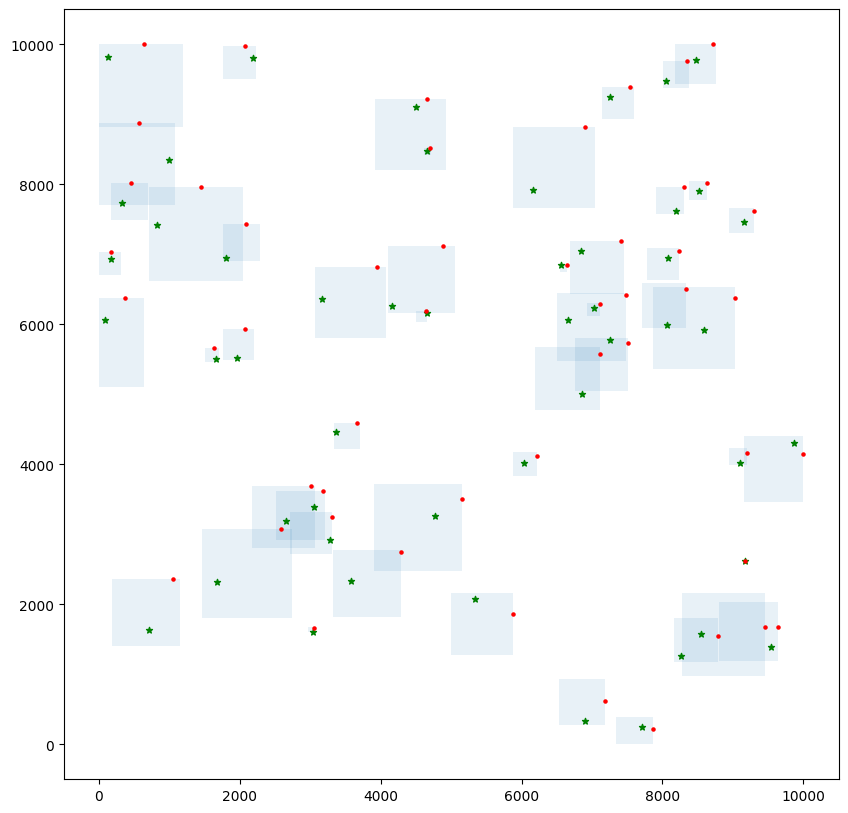

In [67]:
N = 50
final_estimate_points = np.array([ep.estimate_coordinate for ep in estimate_points[:N]])
correct_points = np.array(env.coordinates[:N])
rectangles = env.rectangles[:N]

# 四角形と、四角形内の正解点と予測点を描画
plt.figure(figsize=(10, 10))
ax = plt.gca()
for i, rect in enumerate(rectangles):
    l, r, t, b = rect
    ax.add_patch(matplotlib.patches.Rectangle((l, t), r - l, b - t, alpha=0.1))
ax.scatter(correct_points[:, 0], correct_points[:, 1], color="green", label="correct", s=20, marker="*")
ax.scatter(final_estimate_points[:, 0], final_estimate_points[:, 1], color="red", label="estimate", s=5, marker="o")
plt.show()